In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import os
import sys
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(".."))
df = pd.read_csv('../data/raw/train.csv')
print("Shape:", df.shape)
df.head(3)

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


In [46]:
df.dtypes.value_counts()

# Separate by type
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Numeric columns ({len(num_cols)}):", num_cols)
print(f"\nCategorical columns ({len(cat_cols)}):", cat_cols)

Numeric columns (39): ['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']

Categorical columns (43): ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2

In [47]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].round(2)
print(missing_df)

Pool QC           99.56
Misc Feature      96.38
Alley             93.24
Fence             80.48
Mas Vnr Type      60.58
Fireplace Qu      48.53
Lot Frontage      16.72
Garage Qual        5.43
Garage Yr Blt      5.43
Garage Cond        5.43
Garage Finish      5.43
Garage Type        5.36
Bsmt Exposure      2.83
BsmtFin Type 2     2.76
Bsmt Qual          2.73
Bsmt Cond          2.73
BsmtFin Type 1     2.73
Mas Vnr Area       0.78
Bsmt Full Bath     0.07
Bsmt Half Bath     0.07
Total Bsmt SF      0.03
BsmtFin SF 1       0.03
BsmtFin SF 2       0.03
Garage Area        0.03
Garage Cars        0.03
Bsmt Unf SF        0.03
Electrical         0.03
dtype: float64


Skewness (raw)   : 1.744
Skewness (log1p) : -0.015


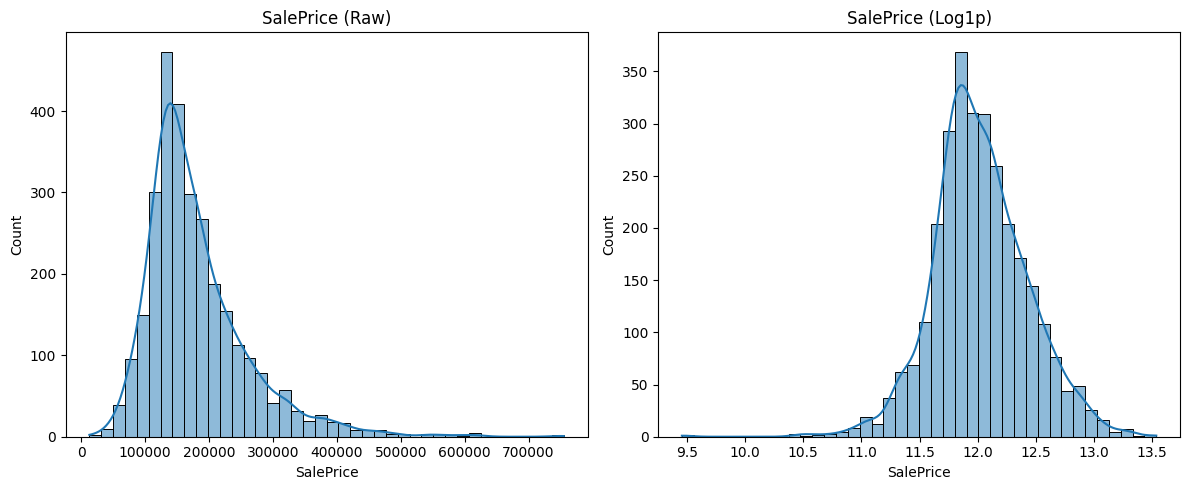

In [48]:

df['SalePrice'].describe().round(2)
print("Skewness (raw)   :", df['SalePrice'].skew().round(3))
print("Skewness (log1p) :", np.log1p(df['SalePrice']).skew().round(3))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['SalePrice'], bins=40, kde=True)
plt.title("SalePrice (Raw)")

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['SalePrice']), bins=40, kde=True)
plt.title("SalePrice (Log1p)")

plt.tight_layout()
plt.show()

In [49]:
# Correlation of all numeric features with SalePrice
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()['SalePrice'].drop(['SalePrice', 'PID'])
corr = corr.abs().sort_values(ascending=False)
print(corr.head(20).round(4))

Overall Qual      0.7993
Gr Liv Area       0.7068
Garage Cars       0.6479
Garage Area       0.6404
Total Bsmt SF     0.6323
1st Flr SF        0.6217
Year Built        0.5584
Full Bath         0.5456
Year Remod/Add    0.5330
Garage Yr Blt     0.5270
Mas Vnr Area      0.5083
TotRms AbvGrd     0.4955
Fireplaces        0.4746
BsmtFin SF 1      0.4329
Lot Frontage      0.3573
Wood Deck SF      0.3271
Open Porch SF     0.3130
Half Bath         0.2851
Bsmt Full Bath    0.2760
2nd Flr SF        0.2694
Name: SalePrice, dtype: float64


Highly skewed features (|skew| > 1.0):
Misc Val           22.000
Pool Area          16.939
Lot Area           12.821
Low Qual Fin SF    12.118
3Ssn Porch         11.404
Kitchen AbvGr       4.314
BsmtFin SF 2        4.140
Enclosed Porch      4.014
Screen Porch        3.957
Bsmt Half Bath      3.941
Mas Vnr Area        2.607
Open Porch SF       2.535
Wood Deck SF        1.843
Lot Frontage        1.499
1st Flr SF          1.469
BsmtFin SF 1        1.416
MS SubClass         1.358
Gr Liv Area         1.274
Total Bsmt SF       1.156
dtype: float64


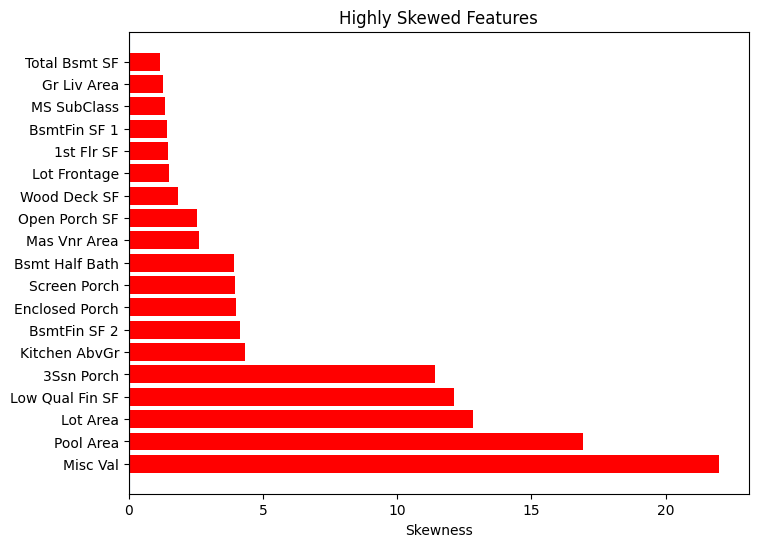

In [50]:
# Skewness of all numeric features
skews = df[num_cols].drop(['PID','SalePrice'], axis=1).skew().sort_values(ascending=False)
skews_high = skews[skews.abs() > 1.0]
print("Highly skewed features (|skew| > 1.0):")
print(skews_high.round(3))
colors = ['red' if x > 0 else 'blue' for x in skews_high]

plt.figure(figsize=(8,6))
plt.barh(skews_high.index, skews_high.values, color=colors)

plt.title("Highly Skewed Features")
plt.xlabel("Skewness")
plt.axvline(0)

plt.show()

In [51]:
for col in cat_cols:
    n_unique = df[col].nunique()
    n_miss = df[col].isnull().sum()
    print(f"{col:20s} unique={n_unique:3d}  missing={n_miss}")

MS Zoning            unique=  7  missing=0
Street               unique=  2  missing=0
Alley                unique=  2  missing=2732
Lot Shape            unique=  4  missing=0
Land Contour         unique=  4  missing=0
Utilities            unique=  3  missing=0
Lot Config           unique=  5  missing=0
Land Slope           unique=  3  missing=0
Neighborhood         unique= 28  missing=0
Condition 1          unique=  9  missing=0
Condition 2          unique=  8  missing=0
Bldg Type            unique=  5  missing=0
House Style          unique=  8  missing=0
Roof Style           unique=  6  missing=0
Roof Matl            unique=  8  missing=0
Exterior 1st         unique= 16  missing=0
Exterior 2nd         unique= 17  missing=0
Mas Vnr Type         unique=  4  missing=1775
Exter Qual           unique=  4  missing=0
Exter Cond           unique=  5  missing=0
Foundation           unique=  6  missing=0
Bsmt Qual            unique=  5  missing=80
Bsmt Cond            unique=  5  missing=80
Bsm

In [52]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Step 1: 60% train, 40% temporary holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)

# Step 2: split the 40% holdout evenly -> 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

total = len(df)
print(f'Train:      {len(X_train):4d} rows  ({len(X_train)/total*100:.0f}%)')
print(f'Validation: {len(X_val):4d} rows  ({len(X_val)/total*100:.0f}%)')
print(f'Test:       {len(X_test):4d} rows  ({len(X_test)/total*100:.0f}%)')
print(f'Total:      {total:4d} rows')

Train:      1758 rows  (60%)
Validation:  586 rows  (20%)
Test:        586 rows  (20%)
Total:      2930 rows


In [53]:
# Garage-related columns — are they null on the same rows?
garage_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Garage Yr Blt', 'Garage Area', 'Garage Cars']
garage_null = X_train[garage_cols].isnull()

print('Garage null overlap (number of rows where each pair is BOTH null):')
overlap = garage_null.T.dot(garage_null)
print(overlap)
print(f'\nRows with any garage null: {garage_null.any(axis=1).sum()}')
print(f'Rows with all garage cols null: {garage_null.all(axis=1).sum()}')
print('\nConclusion: garage nulls are co-occurring -> these houses have no garage.')

Garage null overlap (number of rows where each pair is BOTH null):
               Garage Type  Garage Finish  Garage Qual  Garage Cond  \
Garage Type           True           True         True         True   
Garage Finish         True           True         True         True   
Garage Qual           True           True         True         True   
Garage Cond           True           True         True         True   
Garage Yr Blt         True           True         True         True   
Garage Area          False           True         True         True   
Garage Cars          False           True         True         True   

               Garage Yr Blt  Garage Area  Garage Cars  
Garage Type             True        False        False  
Garage Finish           True         True         True  
Garage Qual             True         True         True  
Garage Cond             True         True         True  
Garage Yr Blt           True         True         True  
Garage Area           

In [54]:
# Basement-related columns — same pattern?
bsmt_cols = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
             'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
bsmt_null = X_train[bsmt_cols].isnull()

print('Basement null co-occurrence:')
print(f'Rows where ALL basement quality cols are null: {bsmt_null[["Bsmt Qual","Bsmt Cond","Bsmt Exposure","BsmtFin Type 1","BsmtFin Type 2"]].all(axis=1).sum()}')
print(f'Rows where any basement area col is null:      {bsmt_null[["BsmtFin SF 1","Total Bsmt SF"]].any(axis=1).sum()}')
print('\nConclusion: categorical bsmt cols null = no basement -> fill with None / 0.')

Basement null co-occurrence:
Rows where ALL basement quality cols are null: 42
Rows where any basement area col is null:      1

Conclusion: categorical bsmt cols null = no basement -> fill with None / 0.


In [56]:
# Mean SalePrice per category — which cats show strong price signal?
key_cats = ['Neighborhood', 'Exter Qual', 'Kitchen Qual', 'Foundation']
for col in key_cats:
    means = df.groupby(col)['SalePrice'].mean().sort_values(ascending=False).round(0)
    print(f"\n{col}:")
    print(means)


Neighborhood:
Neighborhood
NoRidge    330319.0
StoneBr    324229.0
NridgHt    322018.0
GrnHill    280000.0
Veenker    248315.0
Timber     246600.0
Somerst    229707.0
ClearCr    208662.0
Crawfor    207551.0
CollgCr    201803.0
Blmngtn    196662.0
Greens     193531.0
Gilbert    190647.0
NWAmes     188407.0
SawyerW    184070.0
Mitchel    162227.0
NAmes      145097.0
Blueste    143590.0
NPkVill    140711.0
Landmrk    137000.0
Sawyer     136751.0
SWISU      135072.0
Edwards    130843.0
BrkSide    124756.0
OldTown    123992.0
BrDale     105608.0
IDOTRR     103753.0
MeadowV     95756.0
Name: SalePrice, dtype: float64

Exter Qual:
Exter Qual
Ex    377919.0
Gd    230756.0
TA    143374.0
Fa     89924.0
Name: SalePrice, dtype: float64

Kitchen Qual:
Kitchen Qual
Ex    337339.0
Gd    210836.0
TA    139550.0
Po    107500.0
Fa    105907.0
Name: SalePrice, dtype: float64

Foundation:
Foundation
PConc     227069.0
Wood      180900.0
Stone     149787.0
CBlock    148284.0
BrkTil    128107.0
Slab      

In [60]:
# Check for extreme values in GrLivArea vs SalePrice
outliers = df[df['Gr Liv Area'] > 4000]
print(outliers[['PID', 'Gr Liv Area', 'Overall Qual', 'Neighborhood', 'SalePrice']])

# OverallQual — does price scale monotonically?
qual_price = df.groupby('Overall Qual')['SalePrice'].mean().round(0)
print("\nMean price by OverallQual:")
print(qual_price)

            PID  Gr Liv Area  Overall Qual Neighborhood  SalePrice
1498  908154235         5642            10      Edwards     160000
1760  528320050         4476            10      NoRidge     745000
1767  528351010         4316            10      NoRidge     755000
2180  908154195         5095            10      Edwards     183850
2181  908154205         4676            10      Edwards     184750

Mean price by OverallQual:
Overall Qual
1      48725.0
2      52325.0
3      83186.0
4     106485.0
5     134753.0
6     162130.0
7     205026.0
8     270914.0
9     368337.0
10    450217.0
Name: SalePrice, dtype: float64


In [65]:
candidates = ['Overall Qual','Gr Liv Area','Garage Cars','Garage Area',
              'Total Bsmt SF','1st Flr SF','Year Built','Year Remod/Add',
              'Garage Yr Blt','TotRms AbvGrd','BsmtFin SF 1','2nd Flr SF','Lot Area']
corr_matrix = df[candidates].corr().round(2)
print(corr_matrix)

                Overall Qual  Gr Liv Area  Garage Cars  Garage Area  \
Overall Qual            1.00         0.57         0.60         0.56   
Gr Liv Area             0.57         1.00         0.49         0.48   
Garage Cars             0.60         0.49         1.00         0.89   
Garage Area             0.56         0.48         0.89         1.00   
Total Bsmt SF           0.55         0.44         0.44         0.49   
1st Flr SF              0.48         0.56         0.44         0.49   
Year Built              0.60         0.24         0.54         0.48   
Year Remod/Add          0.57         0.32         0.43         0.38   
Garage Yr Blt           0.57         0.27         0.59         0.56   
TotRms AbvGrd           0.38         0.81         0.36         0.33   
BsmtFin SF 1            0.28         0.21         0.26         0.31   
2nd Flr SF              0.24         0.66         0.18         0.13   
Lot Area                0.10         0.29         0.18         0.21   

     

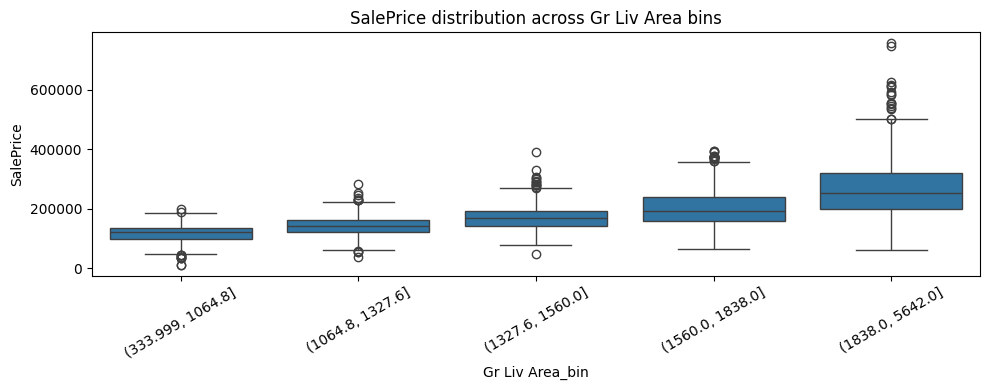

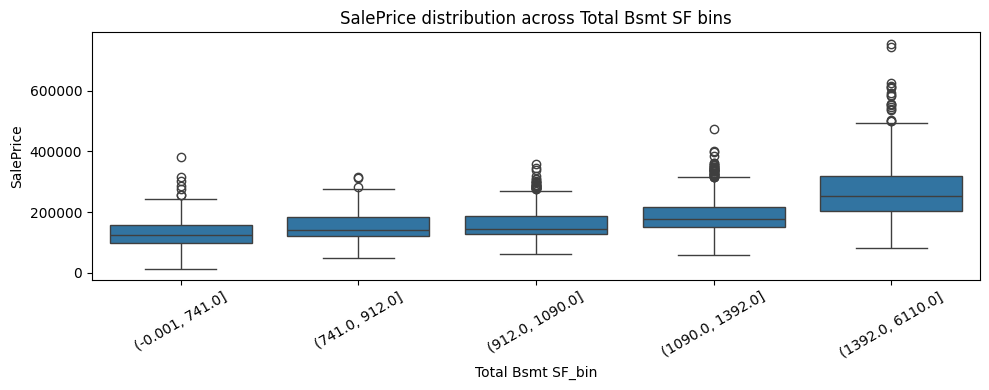

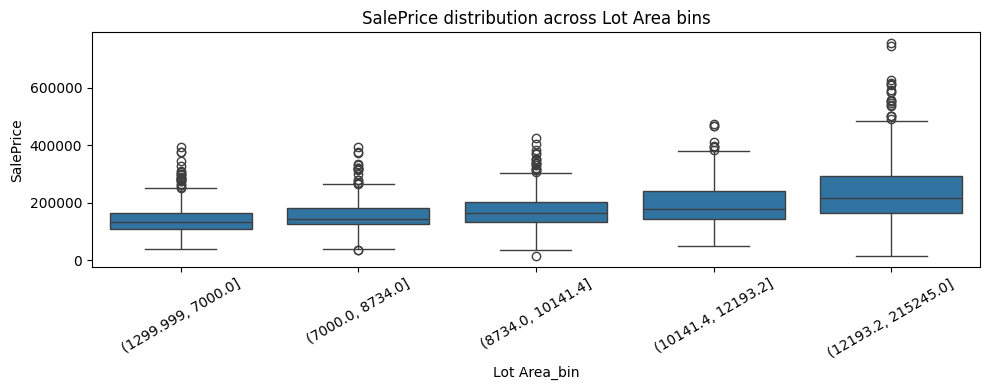

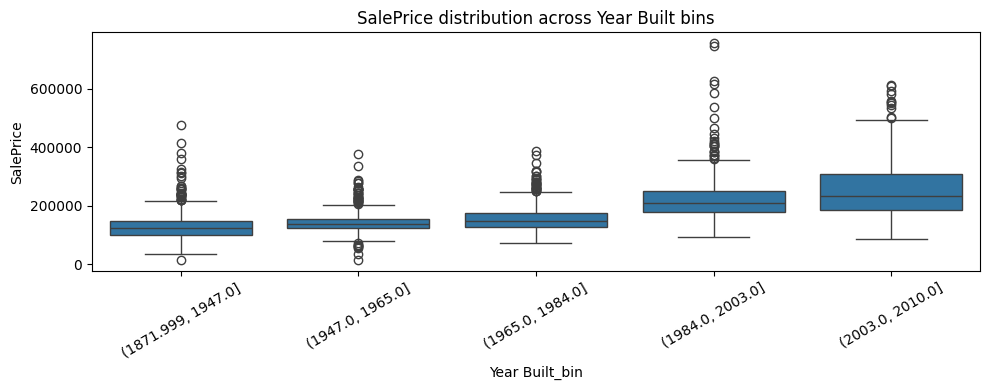

In [66]:
binned_features = ["Gr Liv Area", "Total Bsmt SF", "Lot Area", "Year Built"]

for col in binned_features:
    temp = df[[col, "SalePrice"]].copy()
    temp[f"{col}_bin"] = pd.qcut(temp[col], q=5, duplicates="drop")

    plt.figure(figsize=(10, 4))
    sns.boxplot(data=temp, x=f"{col}_bin", y="SalePrice")
    plt.xticks(rotation=30)
    plt.title(f"SalePrice distribution across {col} bins")
    plt.tight_layout()
    plt.show()

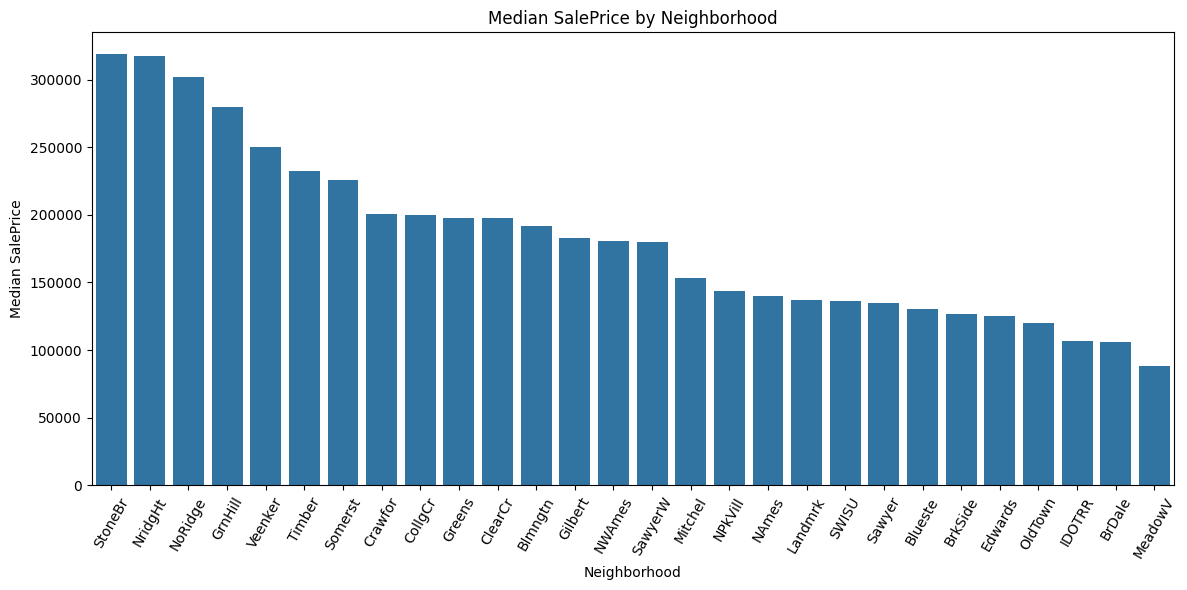

(                median  count
 Neighborhood                 
 StoneBr       319000.0     51
 NridgHt       317750.0    166
 NoRidge       302000.0     71
 GrnHill       280000.0      2
 Veenker       250250.0     24
 Timber        232106.5     72
 Somerst       225500.0    182
 Crawfor       200624.0    103
 CollgCr       200000.0    267
 Greens        198000.0      8,
                 median  count
 Neighborhood                 
 Landmrk       137000.0      1
 SWISU         136200.0     48
 Sawyer        135000.0    151
 Blueste       130500.0     10
 BrkSide       126750.0    108
 Edwards       125000.0    194
 OldTown       119900.0    239
 IDOTRR        106500.0     93
 BrDale        106000.0     30
 MeadowV        88250.0     37)

In [67]:
neigh_stats = (
    df.groupby("Neighborhood")["SalePrice"]
      .agg(["median", "count"])
      .sort_values("median", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=neigh_stats.index, y=neigh_stats["median"])
plt.xticks(rotation=60)
plt.title("Median SalePrice by Neighborhood")
plt.ylabel("Median SalePrice")
plt.tight_layout()
plt.show()

neigh_stats.head(10), neigh_stats.tail(10)

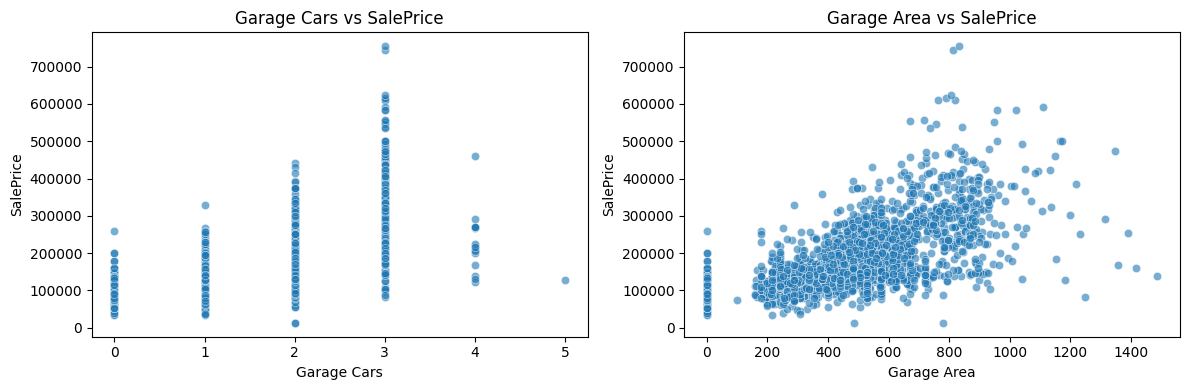

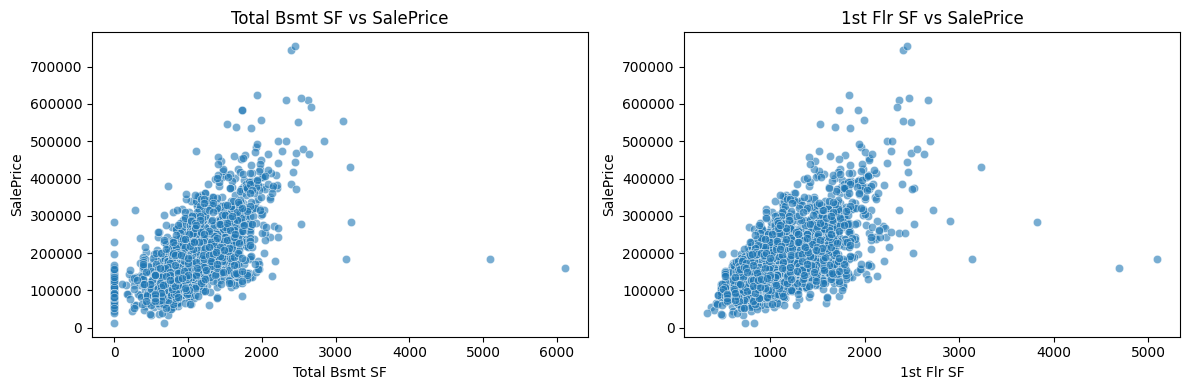

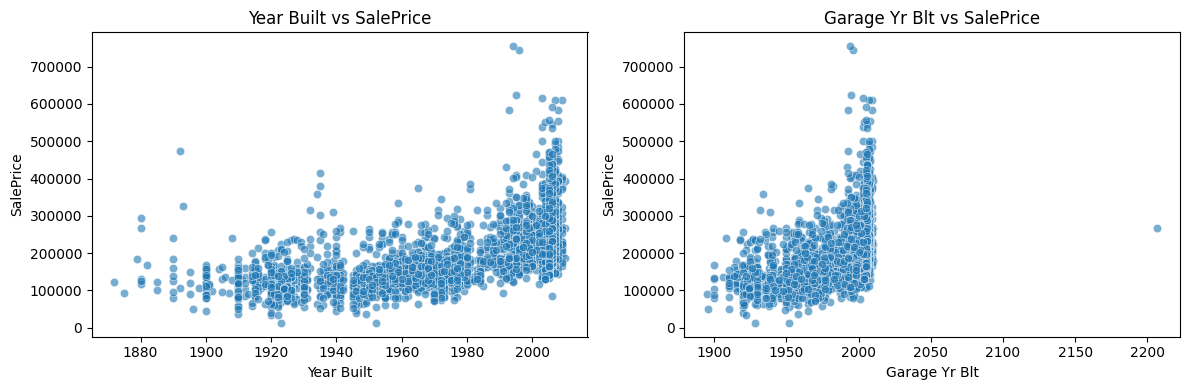

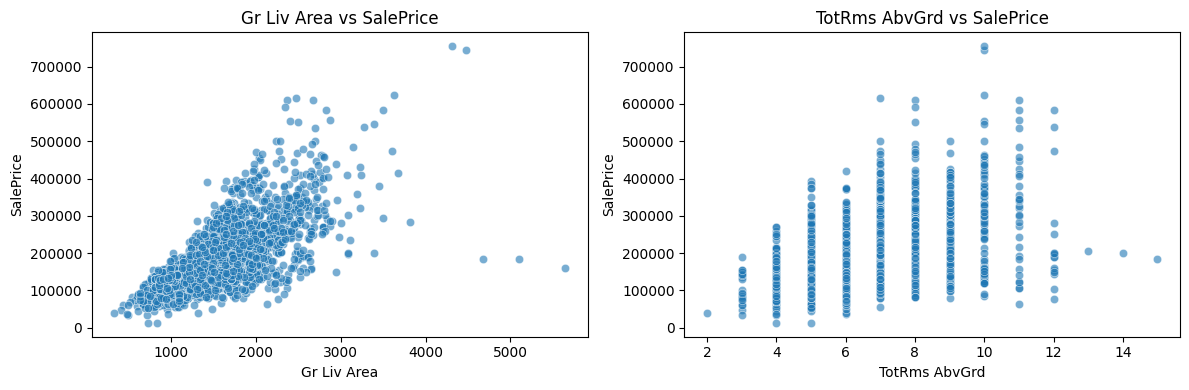

In [75]:
competitor_pairs = [
    ("Garage Cars", "Garage Area"),
    ("Total Bsmt SF", "1st Flr SF"),
    ("Year Built", "Garage Yr Blt"),
    ("Gr Liv Area", "TotRms AbvGrd"),
]

for keep_col, drop_col in competitor_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.scatterplot(data=df, x=keep_col, y="SalePrice", ax=axes[0], alpha=0.6)
    axes[0].set_title(f"{keep_col} vs SalePrice")

    sns.scatterplot(data=df, x=drop_col, y="SalePrice", ax=axes[1], alpha=0.6)
    axes[1].set_title(f"{drop_col} vs SalePrice")

    plt.tight_layout()
    plt.show()

In [97]:
df['House Age'] = 2026 - df['Year Built']

In [ ]:
selected_features = [
    'Overall Qual',
    'Gr Liv Area',
    'Year Built',
    'Neighborhood',
    'Total Bsmt SF',
    'Garage Cars',
    'Full Bath',
    'Lot Area',
    'Bedroom AbvGr',
    'House Style',
    'House Age'    
]

In [99]:
df[selected_features].isnull().sum().sort_values(ascending=False)

Total Bsmt SF    1
Garage Cars      1
Overall Qual     0
Year Built       0
Gr Liv Area      0
Neighborhood     0
Full Bath        0
Lot Area         0
Bedroom AbvGr    0
House Style      0
House Age        0
dtype: int64

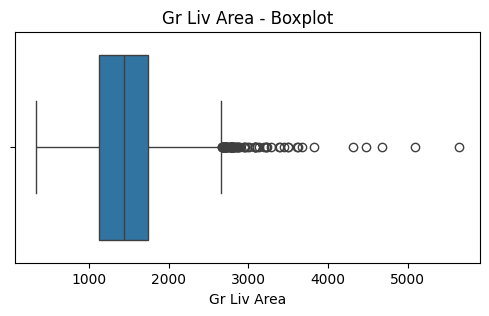

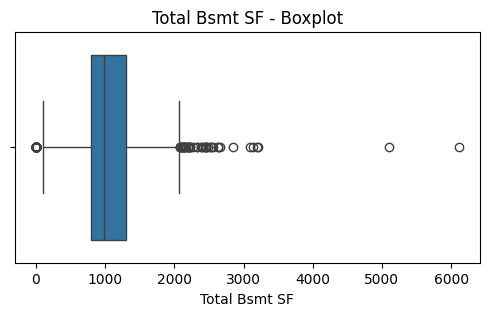

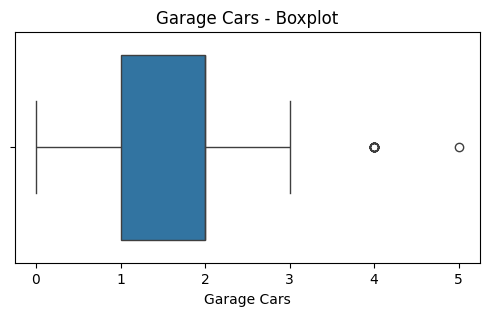

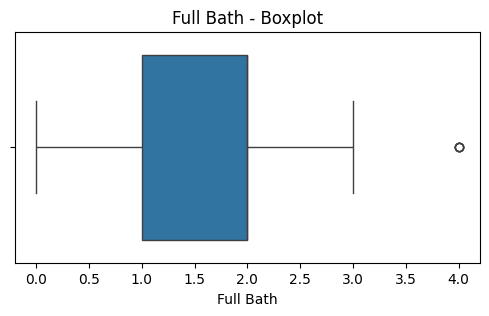

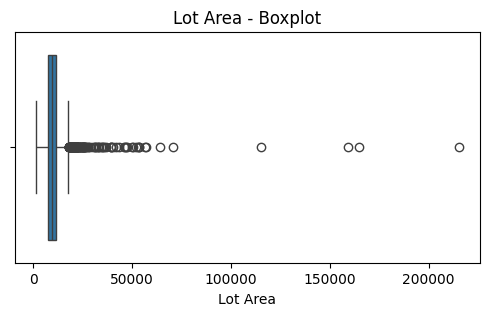

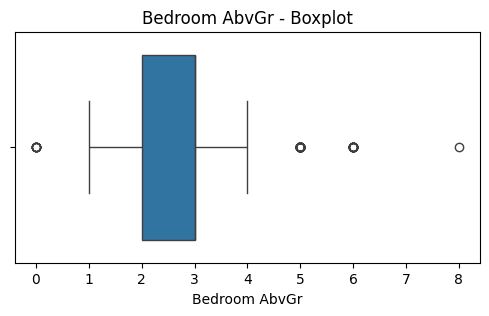

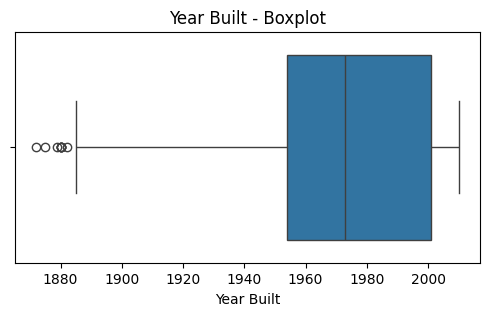

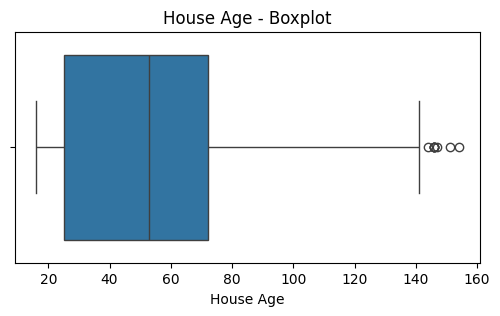

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'Gr Liv Area', 'Total Bsmt SF', 'Garage Cars',
    'Full Bath', 'Lot Area', 'Bedroom AbvGr', 'Year Built', 'House Age'
]

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} - Boxplot")
    plt.show()

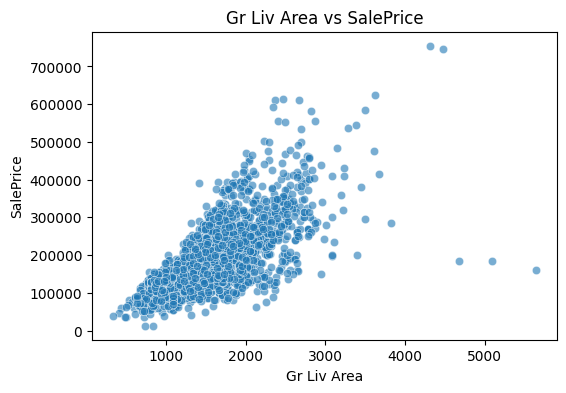

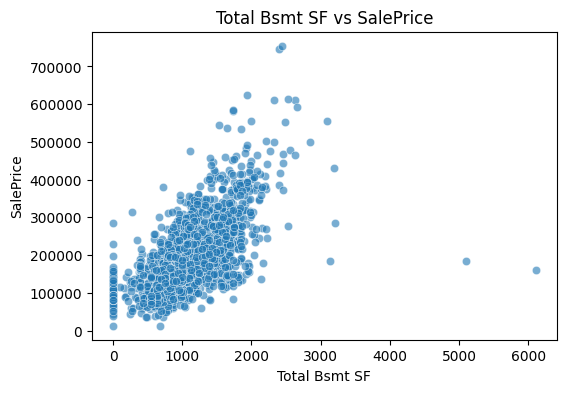

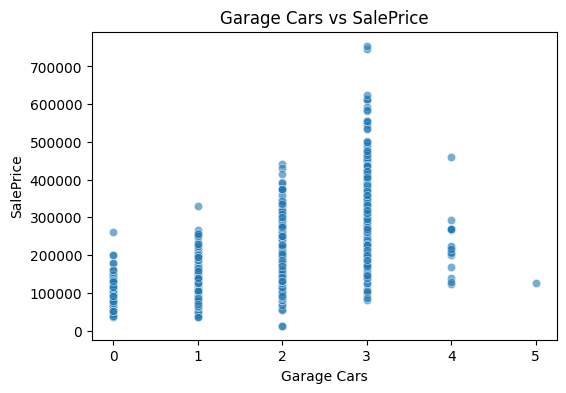

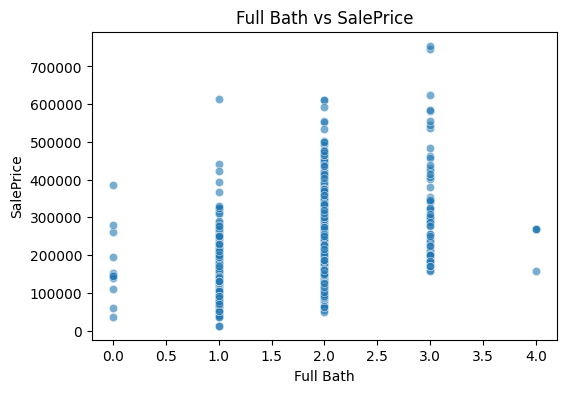

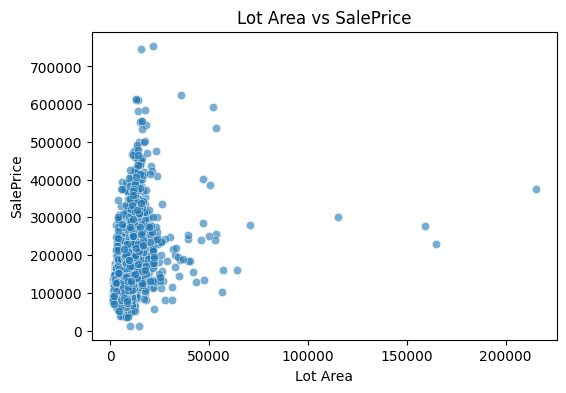

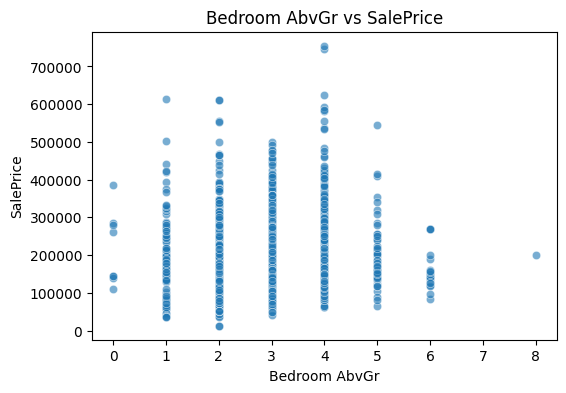

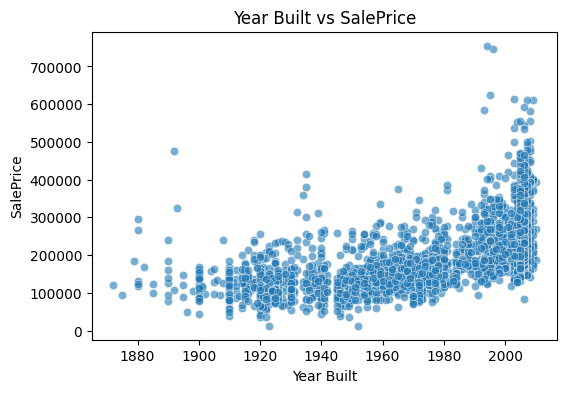

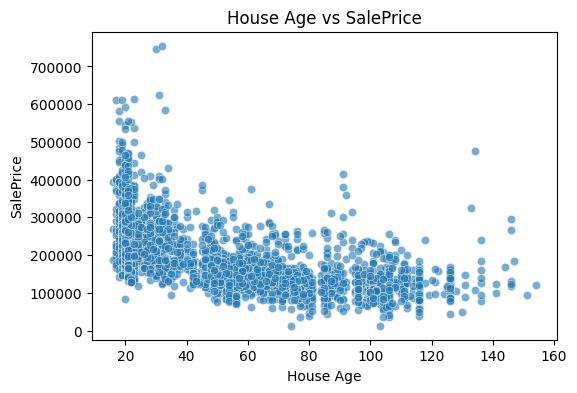

In [101]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y="SalePrice", alpha=0.6)
    plt.title(f"{col} vs SalePrice")
    plt.show()

In [102]:
cat_cols = ['Neighborhood', 'House Style']

for col in cat_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())


Neighborhood unique values:
Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64

House Style unique values:
House Style
1Story    1481
2Story     873
1.5Fin     314
SLvl       128
SFoyer      83
2.5Unf      24
1.5Unf      19
2.5Fin       8
Name: count, dtype: int64


In [103]:
for col in cat_cols:
    print(col, "→", df[col].nunique())

Neighborhood → 28
House Style → 8


In [104]:
df[selected_features].describe()

,Overall Qual,Gr Liv Area,Year Built,Total Bsmt SF,Garage Cars,Full Bath,Lot Area,Bedroom AbvGr,House Age
count,2930.000000,2930.000000,2930.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,6.094881,1499.690444,1971.356314,1051.614544,1.766815,1.566553,10147.921843,2.854266,54.643686
std,1.411026,505.508887,30.245361,440.615067,0.760566,0.552941,7880.017759,0.827731,30.245361
min,1.000000,334.000000,1872.000000,0.000000,0.000000,0.000000,1300.000000,0.000000,16.000000
25%,5.000000,1126.000000,1954.000000,793.000000,1.000000,1.000000,7440.250000,2.000000,25.000000
50%,6.000000,1442.000000,1973.000000,990.000000,2.000000,2.000000,9436.500000,3.000000,53.000000
75%,7.000000,1742.750000,2001.000000,1302.000000,2.000000,2.000000,11555.250000,3.000000,72.000000
max,10.000000,5642.000000,2010.000000,6110.000000,5.000000,4.000000,215245.000000,8.000000,154.000000


In [105]:
for col in df[selected_features].select_dtypes(include='number').columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

Overall Qual: 4 outliers
Gr Liv Area: 75 outliers
Year Built: 9 outliers
Total Bsmt SF: 123 outliers
Garage Cars: 17 outliers
Full Bath: 4 outliers
Lot Area: 127 outliers
Bedroom AbvGr: 78 outliers
House Age: 9 outliers
